In [1]:
# =============================================================================
# CAPSTONE PROJECT: Decoding Barcelona's DNA
# A Data Mining Analysis of FC Barcelona's Playing Style & Performance
# Across La Liga Seasons (2004–2021)
# =============================================================================
# Sections:
#   1. Data Collection
#   2. Feature Engineering
#   3. Exploratory Data Analysis (EDA)
#   4. Classification – Predicting Match Outcomes
#   5. Clustering – Tactical Profiles
#   6. Era Analysis – How Barcelona Changed Over Time
#   7. Association Rules – Common Event Sequences
#   8. Summary & Conclusions
# =============================================================================

# ── INSTALL (run once in terminal if needed) ──────────────────────────────────
# pip install requests pandas numpy matplotlib seaborn scikit-learn xgboost mlxtend tqdm

import requests, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm
from collections import defaultdict

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve,
                             f1_score, accuracy_score)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

import xgboost as xgb

In [2]:
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Colour palette used throughout
ERA_COLORS = {
    "Pre-Pep (2004–2008)":   "#e63946",
    "Pep Era (2008–2012)":    "#2a9d8f",
    "Transition (2012–2016)": "#e9c46a",
    "Decline (2016–2021)":    "#457b9d",
}

In [3]:
# =============================================================================
# SECTION 1 – DATA COLLECTION
# =============================================================================
print("=" * 70)
print("SECTION 1: DATA COLLECTION")
print("=" * 70)

# Competition 11 = La Liga; season_id → label
SEASON_MAP = {
    37: "2004/05", 39: "2006/07", 21: "2009/10", 22: "2010/11",
    23: "2011/12", 24: "2012/13", 25: "2013/14", 26: "2014/15",
    27: "2015/16",  1: "2016/17",  2: "2017/18",  4: "2018/19",
    42: "2019/20", 90: "2020/21",
}

ERA_MAP = {
    "2004/05": "Pre-Pep (2004–2008)", "2006/07": "Pre-Pep (2004–2008)",
    "2009/10": "Pep Era (2008–2012)", "2010/11": "Pep Era (2008–2012)",
    "2011/12": "Pep Era (2008–2012)", "2012/13": "Transition (2012–2016)",
    "2013/14": "Transition (2012–2016)", "2014/15": "Transition (2012–2016)",
    "2015/16": "Transition (2012–2016)", "2016/17": "Decline (2016–2021)",
    "2017/18": "Decline (2016–2021)", "2018/19": "Decline (2016–2021)",
    "2019/20": "Decline (2016–2021)", "2020/21": "Decline (2016–2021)",
}

BASE = "https://raw.githubusercontent.com/statsbomb/open-data/master/data"

def get_json(url, retries=3, delay=1):
    for i in range(retries):
        try:
            r = requests.get(url, timeout=15)
            r.raise_for_status()
            return r.json()
        except Exception as e:
            if i < retries - 1:
                time.sleep(delay)
            else:
                print(f"  ✗ Failed: {url}  ({e})")
                return None

# ── 1.1 Collect all matches ───────────────────────────────────────────────────
all_matches = []

print("\nFetching match lists …")
for sid, label in tqdm(SEASON_MAP.items(), desc="Seasons"):
    data = get_json(f"{BASE}/matches/11/{sid}.json")
    if data is None:
        continue
    for m in data:
        ht = m.get("home_team", {}).get("home_team_name", "")
        at = m.get("away_team", {}).get("away_team_name", "")
        barca_home = "Barcelona" in ht
        barca_away = "Barcelona" in at
        if not (barca_home or barca_away):
            continue
        hs = m.get("home_score", 0) or 0
        as_ = m.get("away_score", 0) or 0
        if barca_home:
            result = "Win" if hs > as_ else ("Draw" if hs == as_ else "Loss")
            barca_goals, opp_goals = hs, as_
            opponent = at
        else:
            result = "Win" if as_ > hs else ("Draw" if hs == as_ else "Loss")
            barca_goals, opp_goals = as_, hs
            opponent = ht
        all_matches.append({
            "match_id":    m["match_id"],
            "season":      label,
            "era":         ERA_MAP[label],
            "barca_home":  int(barca_home),
            "opponent":    opponent,
            "barca_goals": barca_goals,
            "opp_goals":   opp_goals,
            "result":      result,
        })

matches_df = pd.DataFrame(all_matches)
print(f"\n✓ Collected {len(matches_df)} Barcelona matches across {matches_df['season'].nunique()} seasons")
print(matches_df["result"].value_counts().to_string())

# ── 1.2 Fetch event data and build feature matrix ─────────────────────────────
print("\nFetching event data (this takes a few minutes) …")

def parse_events(events):
    """Aggregate a match's raw events into a flat feature dict."""
    feat = defaultdict(float)
    passes, shots, pressures, dribbles, carries = [], [], [], [], []

    for e in events:
        t = e.get("type", {}).get("name", "")
        team = e.get("team", {}).get("name", "")
        is_barca = "Barcelona" in team

        if t == "Pass":
            p = e.get("pass", {})
            outcome = p.get("outcome", {}).get("name", "Complete")
            length  = p.get("length", 0) or 0
            if is_barca:
                feat["barca_passes"] += 1
                feat["barca_pass_length_total"] += length
                if outcome == "Complete":
                    feat["barca_passes_complete"] += 1
                if p.get("switch"):
                    feat["barca_switches"] += 1
                if p.get("through_ball"):
                    feat["barca_through_balls"] += 1
                if p.get("goal_assist"):
                    feat["barca_key_passes"] += 1
            else:
                feat["opp_passes"] += 1
                if outcome == "Complete":
                    feat["opp_passes_complete"] += 1

        elif t == "Shot":
            s = e.get("shot", {})
            xg = s.get("statsbomb_xg", 0) or 0
            outcome = s.get("outcome", {}).get("name", "")
            if is_barca:
                feat["barca_shots"] += 1
                feat["barca_xg"] += xg
                if outcome == "Saved":
                    feat["barca_shots_on_target"] += 1
                if outcome == "Goal":
                    feat["barca_shots_on_target"] += 1

        elif t == "Pressure":
            if is_barca:
                feat["barca_pressures"] += 1
            else:
                feat["opp_pressures"] += 1

        elif t == "Dribble":
            if is_barca:
                feat["barca_dribbles"] += 1
                if e.get("dribble", {}).get("outcome", {}).get("name") == "Complete":
                    feat["barca_dribbles_complete"] += 1

        elif t == "Carry":
            if is_barca:
                feat["barca_carries"] += 1

        elif t == "Ball Receipt*":
            if is_barca:
                feat["barca_touches"] += 1

        elif t == "Foul Committed":
            if is_barca:
                feat["barca_fouls"] += 1
            else:
                feat["opp_fouls"] += 1

        elif t == "Interception":
            if is_barca:
                feat["barca_interceptions"] += 1

        elif t == "Block":
            if is_barca:
                feat["barca_blocks"] += 1

        elif t == "Clearance":
            if is_barca:
                feat["barca_clearances"] += 1

    # Derived metrics
    total_p = feat["barca_passes"] + feat["opp_passes"]
    feat["possession_pct"] = (feat["barca_passes"] / total_p * 100) if total_p else 50
    feat["pass_accuracy"]  = (feat["barca_passes_complete"] / feat["barca_passes"] * 100) if feat["barca_passes"] else 0
    feat["avg_pass_length"] = (feat["barca_pass_length_total"] / feat["barca_passes"]) if feat["barca_passes"] else 0
    feat["opp_pass_accuracy"] = (feat["opp_passes_complete"] / feat["opp_passes"] * 100) if feat["opp_passes"] else 0
    feat["shot_accuracy"]  = (feat["barca_shots_on_target"] / feat["barca_shots"] * 100) if feat["barca_shots"] else 0
    feat["dribble_success"] = (feat["barca_dribbles_complete"] / feat["barca_dribbles"] * 100) if feat["barca_dribbles"] else 0

    return dict(feat)

event_features = []
failed = 0

for _, row in tqdm(matches_df.iterrows(), total=len(matches_df), desc="Events"):
    events = get_json(f"{BASE}/events/{row['match_id']}.json")
    if events is None:
        failed += 1
        continue
    feat = parse_events(events)
    feat["match_id"] = row["match_id"]
    event_features.append(feat)

events_df = pd.DataFrame(event_features).fillna(0)
df = matches_df.merge(events_df, on="match_id", how="inner")

print(f"\n✓ Event features collected for {len(df)} matches ({failed} failed)")
print(f"  Feature columns: {events_df.shape[1] - 1}")

SECTION 1: DATA COLLECTION

Fetching match lists …


Seasons: 100%|██████████| 14/14 [00:02<00:00,  5.77it/s]



✓ Collected 449 Barcelona matches across 14 seasons
result
Win     332
Draw     74
Loss     43

Fetching event data (this takes a few minutes) …


Events: 100%|██████████| 449/449 [03:50<00:00,  1.95it/s]


✓ Event features collected for 449 matches (0 failed)
  Feature columns: 28


In [4]:
# =============================================================================
# SECTION 2 – FEATURE ENGINEERING
# =============================================================================
print("\n" + "=" * 70)
print("SECTION 2: FEATURE ENGINEERING")
print("=" * 70)

# Encode target
le = LabelEncoder()
df["result_enc"] = le.fit_transform(df["result"])   # Draw=0, Loss=1, Win=2

FEATURE_COLS = [
    "barca_passes", "barca_passes_complete", "pass_accuracy", "avg_pass_length",
    "possession_pct", "barca_shots", "barca_shots_on_target", "barca_xg",
    "shot_accuracy", "barca_pressures", "opp_pressures", "barca_dribbles",
    "barca_dribbles_complete", "dribble_success", "barca_carries", "barca_touches",
    "barca_fouls", "opp_fouls", "barca_interceptions", "barca_blocks",
    "barca_clearances", "barca_switches", "barca_through_balls", "barca_key_passes",
    "opp_passes", "opp_pass_accuracy", "barca_home",
]
# Keep only columns that exist in df
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

X = df[FEATURE_COLS].copy()
y = df["result_enc"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\n✓ Feature matrix shape: {X.shape}")
print(f"  Class distribution:\n{df['result'].value_counts().to_string()}")


SECTION 2: FEATURE ENGINEERING

✓ Feature matrix shape: (449, 27)
  Class distribution:
result
Win     332
Draw     74
Loss     43



SECTION 3: EXPLORATORY DATA ANALYSIS


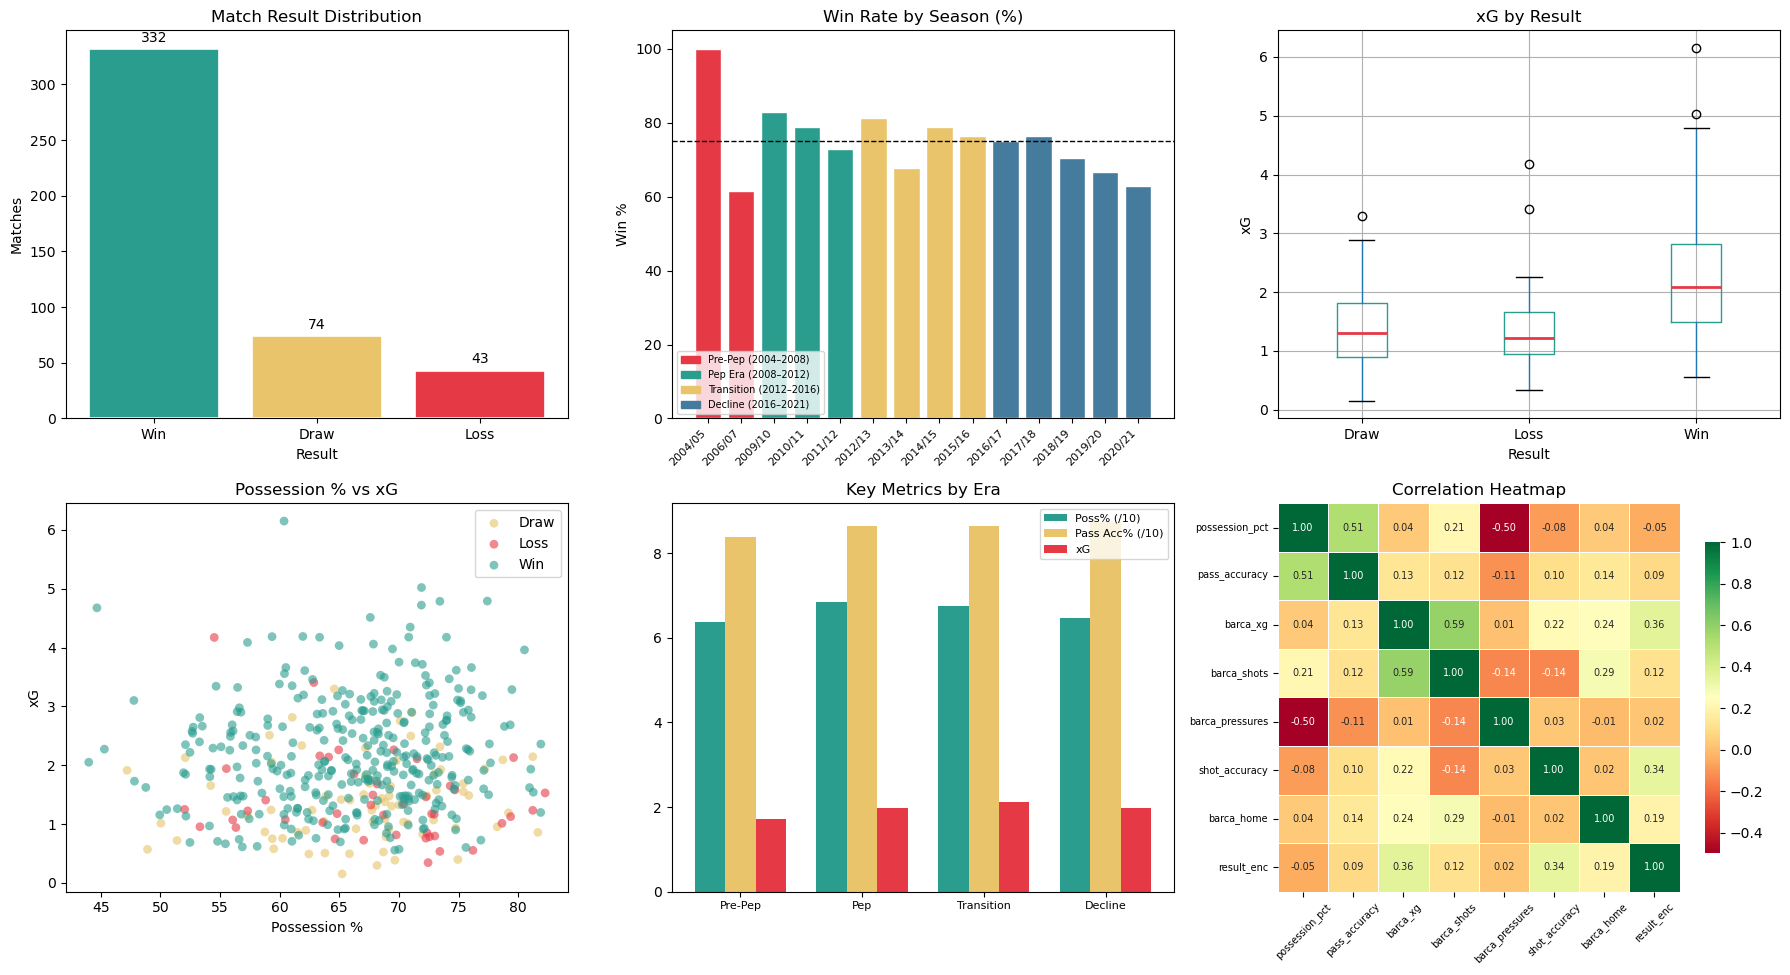

✓ EDA charts saved to eda_overview.png


In [5]:
# =============================================================================
# SECTION 3 – EXPLORATORY DATA ANALYSIS
# =============================================================================
print("\n" + "=" * 70)
print("SECTION 3: EXPLORATORY DATA ANALYSIS")
print("=" * 70)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Barcelona La Liga – Exploratory Data Analysis", fontsize=16, fontweight="bold")

# 3.1 Results distribution
ax = axes[0, 0]
counts = df["result"].value_counts()
colors = ["#2a9d8f", "#e9c46a", "#e63946"]
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor="white", linewidth=1.2)
ax.bar_label(bars, padding=3)
ax.set_title("Match Result Distribution")
ax.set_ylabel("Matches")
ax.set_xlabel("Result")

# 3.2 Win rate by season
ax = axes[0, 1]
win_rate = df.groupby("season")["result"].apply(lambda x: (x == "Win").mean() * 100)
seasons_sorted = list(SEASON_MAP.values())
win_rate = win_rate.reindex([s for s in seasons_sorted if s in win_rate.index])
era_c = [ERA_COLORS[ERA_MAP[s]] for s in win_rate.index]
bars = ax.bar(win_rate.index, win_rate.values, color=era_c, edgecolor="white")
ax.set_title("Win Rate by Season (%)")
ax.set_ylabel("Win %")
ax.set_xticklabels(win_rate.index, rotation=45, ha="right", fontsize=8)
ax.axhline(win_rate.mean(), color="black", linestyle="--", linewidth=1, label=f"Avg {win_rate.mean():.1f}%")
ax.legend(fontsize=8)
patches = [mpatches.Patch(color=v, label=k) for k, v in ERA_COLORS.items()]
ax.legend(handles=patches, fontsize=7, loc="lower left")

# 3.3 xG by result
ax = axes[0, 2]
df.boxplot(column="barca_xg", by="result", ax=ax,
           boxprops=dict(color="#2a9d8f"), medianprops=dict(color="#e63946", linewidth=2))
ax.set_title("Expected Goals (xG) by Result")
ax.set_xlabel("Result")
ax.set_ylabel("xG")
plt.sca(ax); plt.title("xG by Result"); plt.suptitle("")

# 3.4 Possession vs xG
ax = axes[1, 0]
result_colors_map = {"Win": "#2a9d8f", "Draw": "#e9c46a", "Loss": "#e63946"}
for res, grp in df.groupby("result"):
    ax.scatter(grp["possession_pct"], grp["barca_xg"],
               c=result_colors_map[res], label=res, alpha=0.6, s=40, edgecolors="none")
ax.set_title("Possession % vs xG")
ax.set_xlabel("Possession %")
ax.set_ylabel("xG")
ax.legend()

# 3.5 Avg key metrics by era
ax = axes[1, 1]
era_metrics = df.groupby("era")[["possession_pct", "pass_accuracy", "barca_xg"]].mean()
era_metrics = era_metrics.reindex([e for e in ERA_COLORS if e in era_metrics.index])
x_pos = np.arange(len(era_metrics))
width = 0.25
ax.bar(x_pos - width, era_metrics["possession_pct"] / 100 * 10, width, label="Poss% (/10)", color="#2a9d8f")
ax.bar(x_pos,         era_metrics["pass_accuracy"]  / 100 * 10, width, label="Pass Acc% (/10)", color="#e9c46a")
ax.bar(x_pos + width, era_metrics["barca_xg"],                  width, label="xG", color="#e63946")
ax.set_xticks(x_pos)
ax.set_xticklabels([e.split(" ")[0] for e in era_metrics.index], fontsize=8)
ax.set_title("Key Metrics by Era")
ax.legend(fontsize=8)

# 3.6 Correlation heatmap
ax = axes[1, 2]
corr_cols = ["possession_pct", "pass_accuracy", "barca_xg", "barca_shots",
             "barca_pressures", "shot_accuracy", "barca_home", "result_enc"]
corr_cols = [c for c in corr_cols if c in df.columns]
corr = df[corr_cols].corr()
sns.heatmap(corr, ax=ax, annot=True, fmt=".2f", cmap="RdYlGn",
            linewidths=0.5, annot_kws={"size": 7}, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Heatmap")
ax.tick_params(axis="x", rotation=45, labelsize=7)
ax.tick_params(axis="y", rotation=0,  labelsize=7)

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ EDA charts saved to eda_overview.png")


SECTION 4: CLASSIFICATION – PREDICTING MATCH OUTCOMES
  KNN sweep: 28 configs tested
  Best params : {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
  Best CV F1  : 0.426

Top 5 KNN configurations:
k  weights    metric  CV F1 (mean)  CV F1 (std)
3 distance manhattan      0.426319     0.059361
3  uniform manhattan      0.418954     0.048759
3  uniform euclidean      0.406289     0.059246
5  uniform euclidean      0.405616     0.087597
5 distance euclidean      0.392034     0.076150
  Decision Tree: Acc=0.622  F1=0.381  CV=0.390±0.075
  Random Forest: Acc=0.722  F1=0.399  CV=0.401±0.057
  Gradient Boosting: Acc=0.767  F1=0.501  CV=0.429±0.034
  XGBoost: Acc=0.722  F1=0.405  CV=0.409±0.049
  KNN (k=3, distance, manhattan): Acc=0.678  F1=0.375  CV=0.416±0.045

                         Model Test Accuracy Macro F1 CV F1 (mean) CV F1 (std)
                 Decision Tree         0.622    0.381        0.390       0.075
                 Random Forest         0.722    0.399    

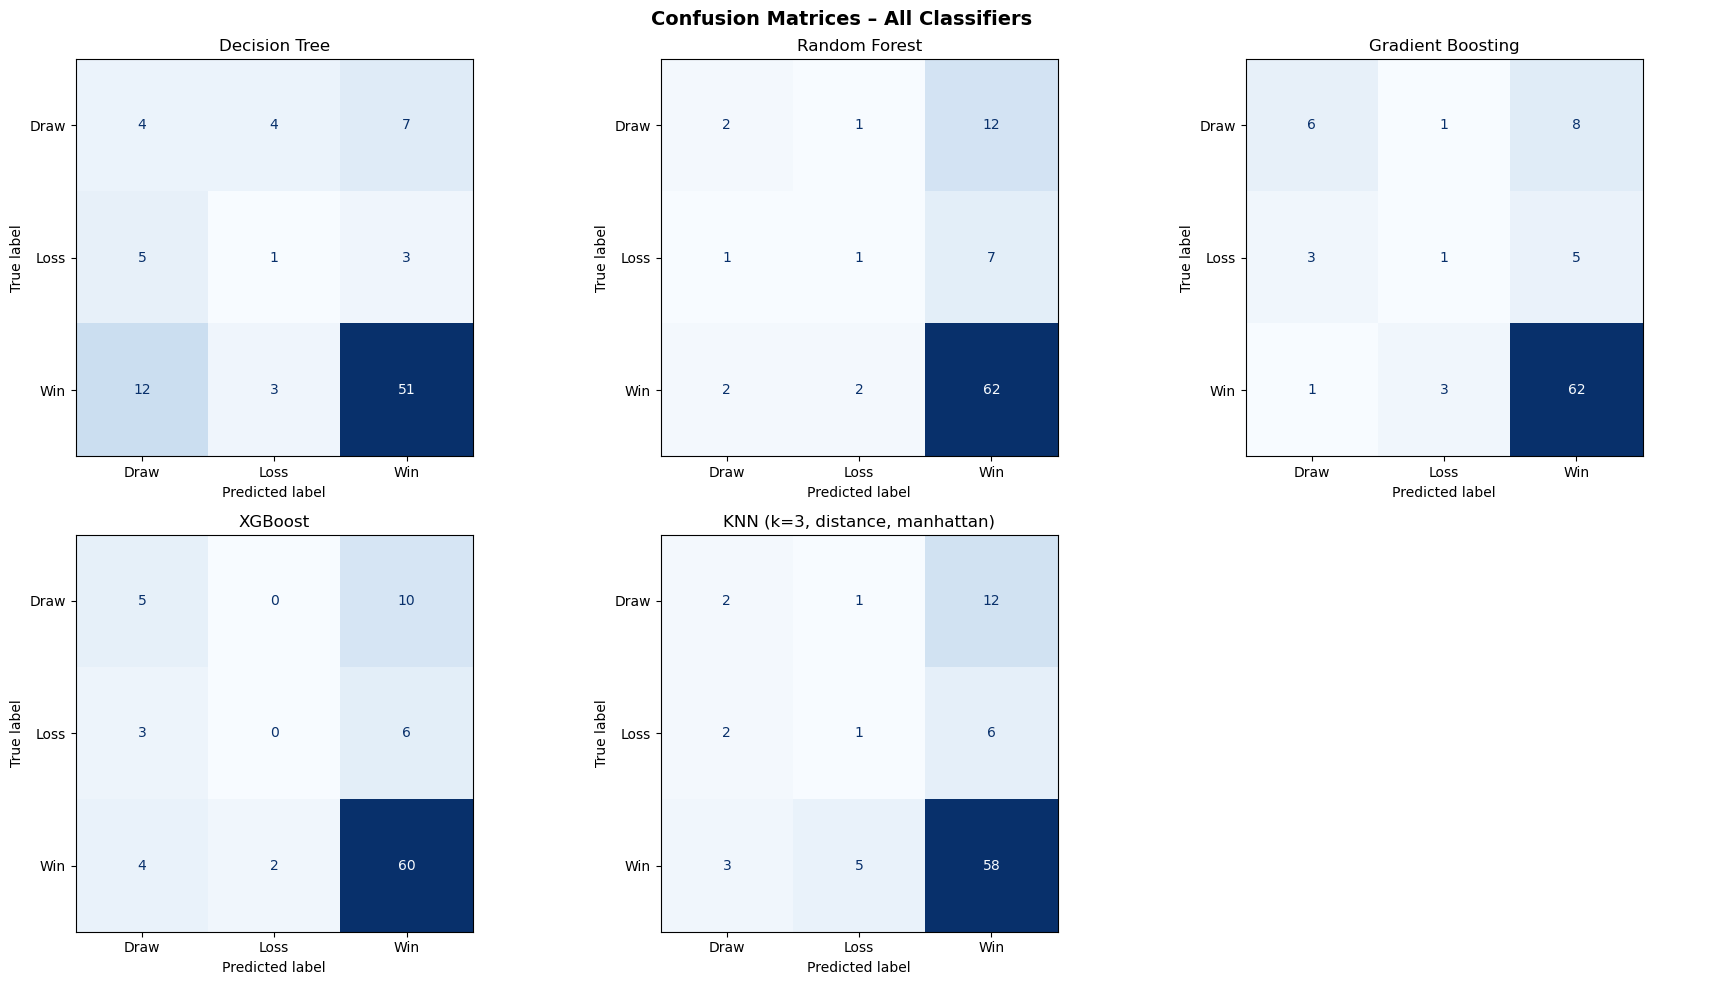

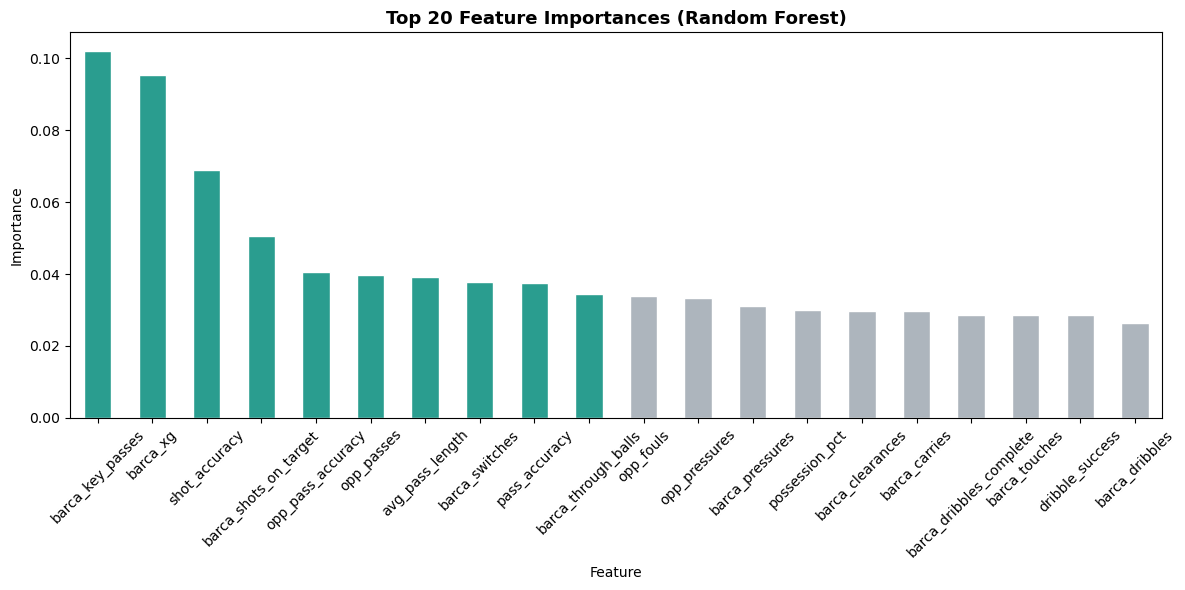


Top 5 features:
barca_key_passes         0.102163
barca_xg                 0.095358
shot_accuracy            0.068916
barca_shots_on_target    0.050691
opp_pass_accuracy        0.040553


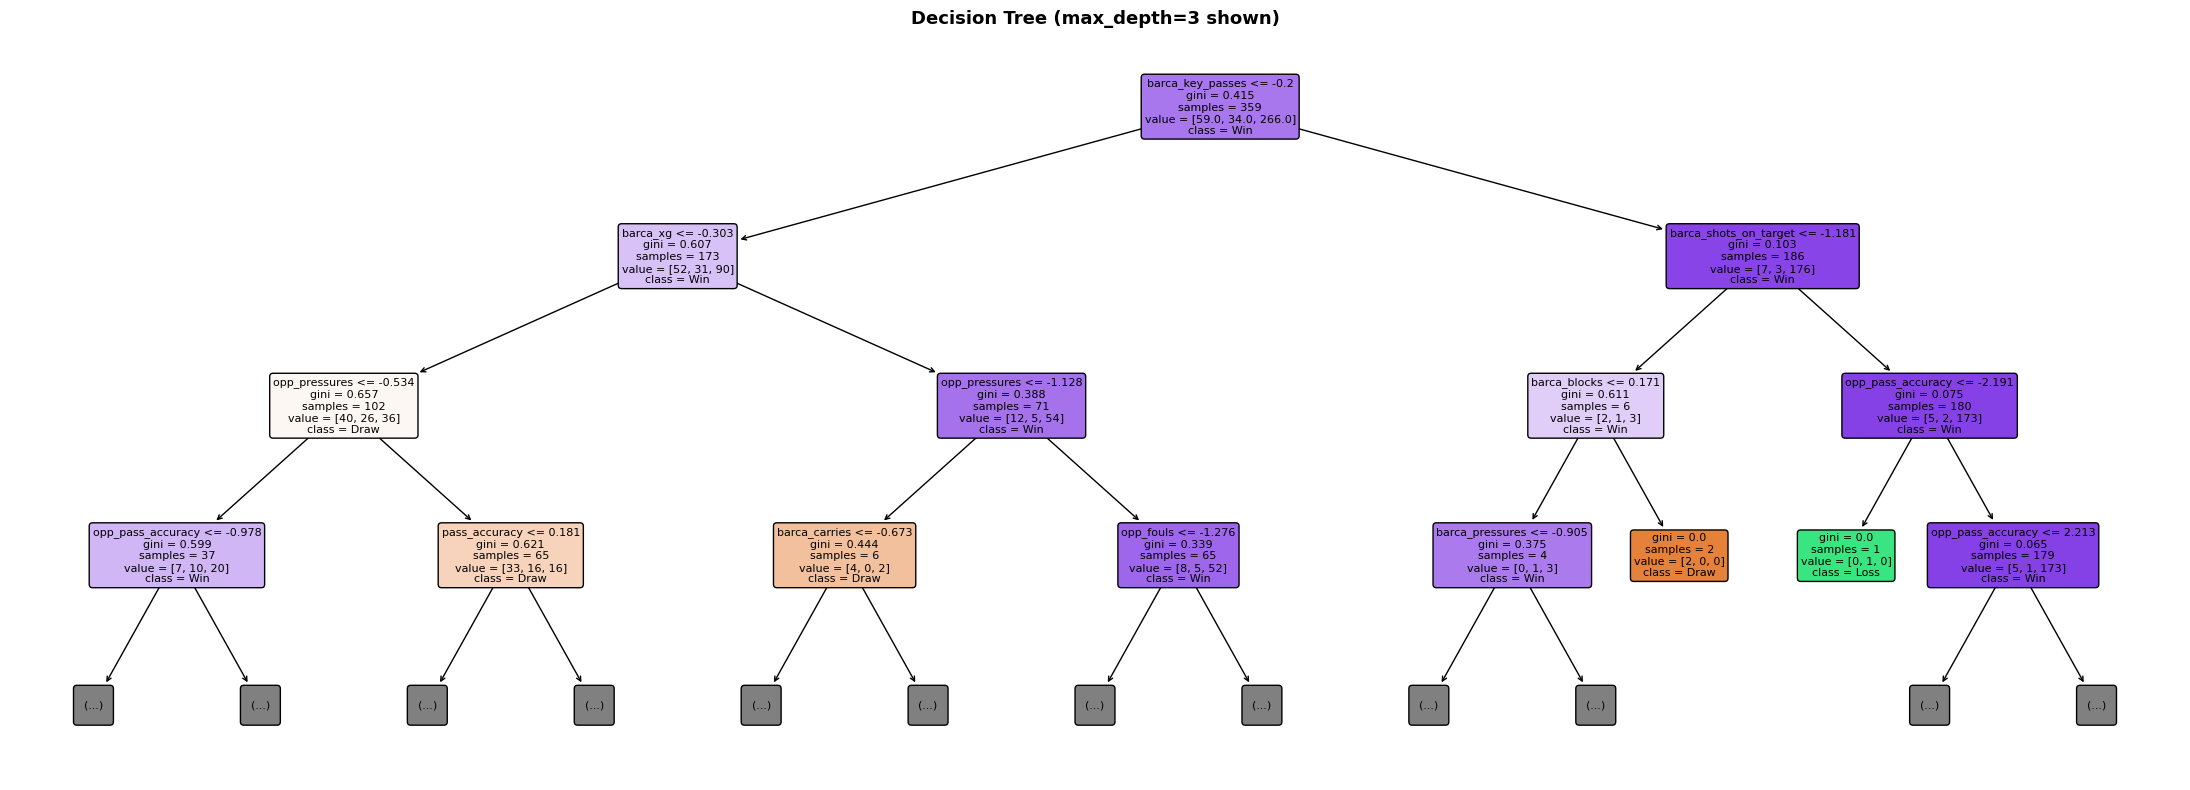

In [6]:
# =============================================================================
# SECTION 4 – CLASSIFICATION
# =============================================================================
print("\n" + "=" * 70)
print("SECTION 4: CLASSIFICATION – PREDICTING MATCH OUTCOMES")
print("=" * 70)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# ── KNN hyperparameter sweep ─────────────────────────────────────────────────
# Try multiple KNN configurations and pick the best by CV macro-F1.
# 7 values of k × 2 weighting schemes × 2 distance metrics = 28 configs.
knn_param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "weights":     ["uniform", "distance"],
    "metric":      ["euclidean", "manhattan"],
}
knn_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
knn_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=knn_param_grid,
    scoring="f1_macro",
    cv=knn_cv,
    n_jobs=-1,
)
knn_search.fit(X_train, y_train)
best_knn = knn_search.best_estimator_
print(f"  KNN sweep: {len(knn_search.cv_results_['params'])} configs tested")
print(f"  Best params : {knn_search.best_params_}")
print(f"  Best CV F1  : {knn_search.best_score_:.3f}")

# Top 5 configurations from the sweep
knn_cv_df = (pd.DataFrame(knn_search.cv_results_)
             [["param_n_neighbors", "param_weights", "param_metric",
               "mean_test_score", "std_test_score"]]
             .sort_values("mean_test_score", ascending=False)
             .head(5)
             .reset_index(drop=True))
knn_cv_df.columns = ["k", "weights", "metric", "CV F1 (mean)", "CV F1 (std)"]
print(f"\nTop 5 KNN configurations:\n{knn_cv_df.to_string(index=False)}")

knn_label = (f"KNN (k={knn_search.best_params_['n_neighbors']}, "
             f"{knn_search.best_params_['weights']}, "
             f"{knn_search.best_params_['metric']})")

models = {
    "Decision Tree":       DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, max_depth=8,
                                                  random_state=42, class_weight="balanced"),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                      max_depth=4, random_state=42),
    "XGBoost":             xgb.XGBClassifier(n_estimators=200, learning_rate=0.05,
                                             max_depth=4, use_label_encoder=False,
                                             eval_metric="mlogloss", random_state=42),
    knn_label:             best_knn,
}

results_table = []
trained = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cv_scores = cross_val_score(model, X_scaled, y, cv=cv, scoring="f1_macro")
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average="macro")
    results_table.append({
        "Model": name,
        "Test Accuracy": f"{acc:.3f}",
        "Macro F1": f"{f1:.3f}",
        "CV F1 (mean)": f"{cv_scores.mean():.3f}",
        "CV F1 (std)":  f"{cv_scores.std():.3f}",
    })
    trained[name] = (model, y_pred)
    print(f"  {name}: Acc={acc:.3f}  F1={f1:.3f}  CV={cv_scores.mean():.3f}±{cv_scores.std():.3f}")

results_df = pd.DataFrame(results_table)
print(f"\n{results_df.to_string(index=False)}")

# ── 4.1 Confusion matrices ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Confusion Matrices – All Classifiers", fontsize=14, fontweight="bold")
class_names = le.classes_

axes_flat = axes.flatten()
for ax, (name, (model, y_pred)) in zip(axes_flat, trained.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)

# Hide any unused subplots
for ax in axes_flat[len(trained):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 4.2 Feature importance (Random Forest) ───────────────────────────────────
rf_model = trained["Random Forest"][0]
importances = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors_fi = ["#2a9d8f" if i < 10 else "#adb5bd" for i in range(len(importances))]
importances.head(20).plot(kind="bar", ax=ax, color=colors_fi[:20], edgecolor="white")
ax.set_title("Top 20 Feature Importances (Random Forest)", fontsize=13, fontweight="bold")
ax.set_ylabel("Importance")
ax.set_xlabel("Feature")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nTop 5 features:\n{importances.head(5).to_string()}")

# ── 4.3 Decision Tree visualisation ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(trained["Decision Tree"][0], feature_names=FEATURE_COLS,
          class_names=class_names, filled=True, rounded=True,
          fontsize=8, max_depth=3, ax=ax)
ax.set_title("Decision Tree (max_depth=3 shown)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("decision_tree.png", dpi=150, bbox_inches="tight")
plt.show()


SECTION 5: CLUSTERING – TACTICAL PROFILES


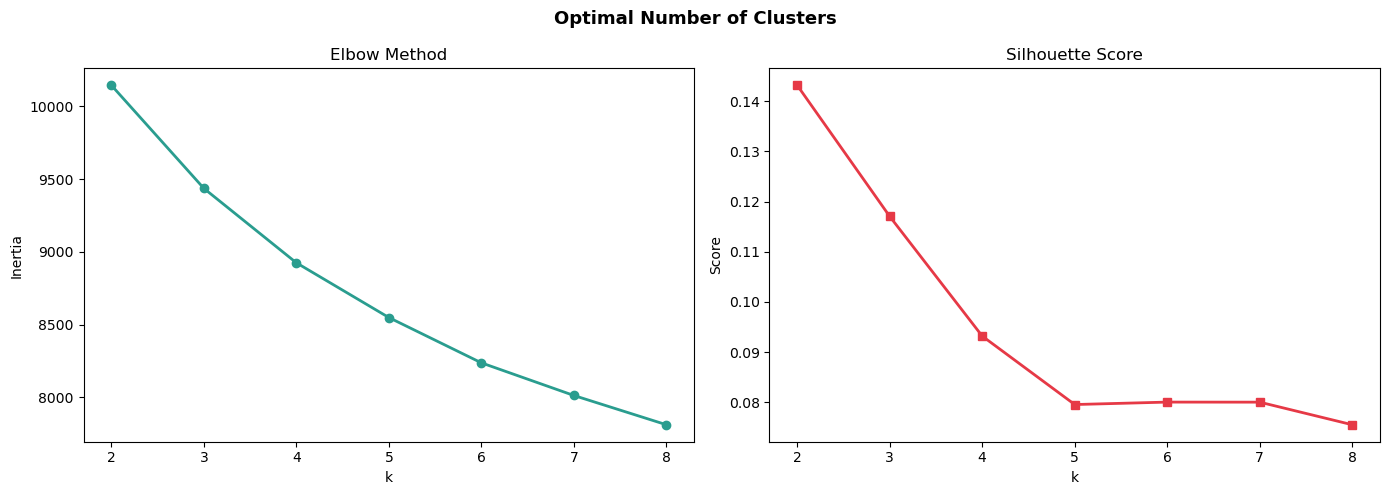

  Best k by silhouette: 2


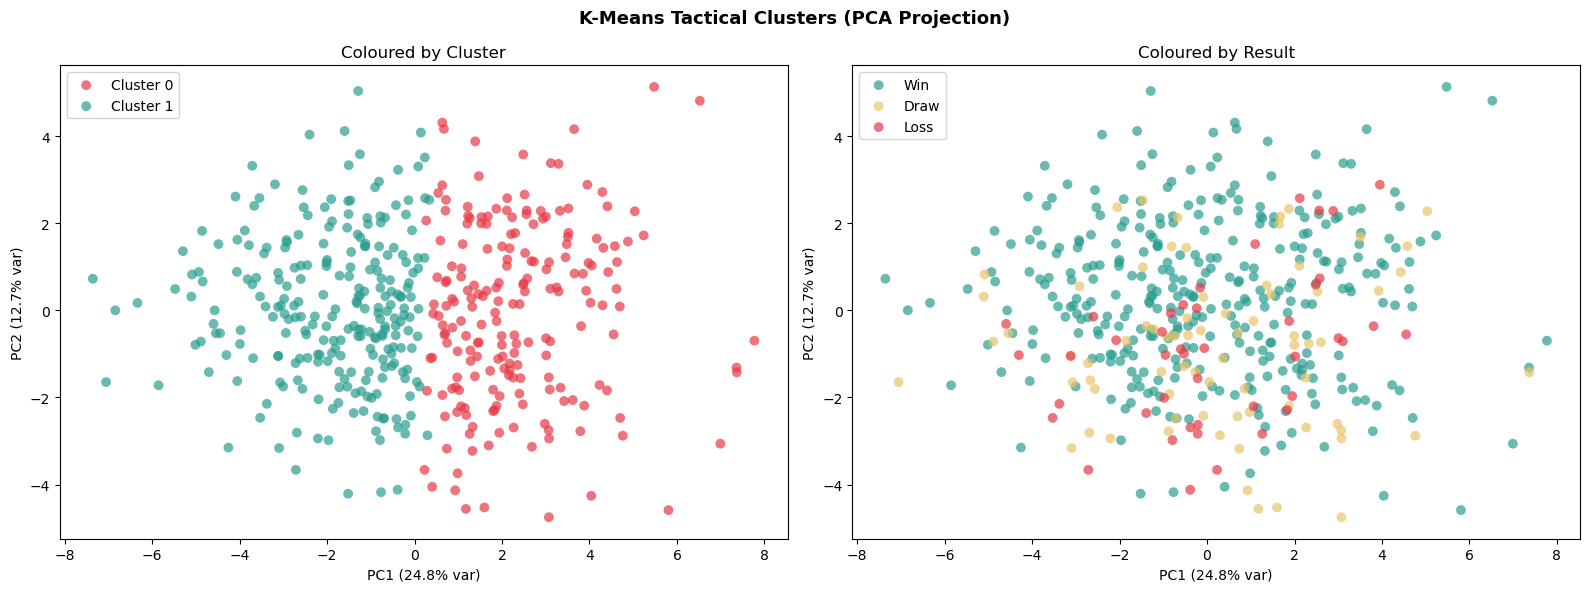


Cluster Profiles (mean values):
         possession_pct  pass_accuracy  avg_pass_length  barca_xg  barca_shots  barca_pressures  barca_dribbles  shot_accuracy
cluster                                                                                                                       
0                 60.23          84.39            19.79      1.83        14.01           138.74           26.99          43.62
1                 71.24          88.49            18.58      2.13        16.73           116.36           28.03          43.58

Cluster Labels:
                      label
cluster                    
0        Dominant Tiki-Taka
1        Dominant Tiki-Taka

Win Rate by Cluster:
     cluster_label  win_rate
Dominant Tiki-Taka 73.942094


In [7]:
# =============================================================================
# SECTION 5 – CLUSTERING (TACTICAL PROFILES)
# =============================================================================
print("\n" + "=" * 70)
print("SECTION 5: CLUSTERING – TACTICAL PROFILES")
print("=" * 70)

# ── 5.1 Find optimal k (elbow + silhouette) ───────────────────────────────────
inertias, sil_scores = [], []
K_RANGE = range(2, 9)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Optimal Number of Clusters", fontsize=13, fontweight="bold")

ax1.plot(K_RANGE, inertias, "o-", color="#2a9d8f", linewidth=2)
ax1.set_title("Elbow Method"); ax1.set_xlabel("k"); ax1.set_ylabel("Inertia")

ax2.plot(K_RANGE, sil_scores, "s-", color="#e63946", linewidth=2)
ax2.set_title("Silhouette Score"); ax2.set_xlabel("k"); ax2.set_ylabel("Score")

plt.tight_layout()
plt.savefig("cluster_selection.png", dpi=150, bbox_inches="tight")
plt.show()

best_k = K_RANGE.start + int(np.argmax(sil_scores))
print(f"  Best k by silhouette: {best_k}")

# ── 5.2 Final KMeans ─────────────────────────────────────────────────────────
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["cluster"] = km_final.fit_predict(X_scaled)

# ── 5.3 PCA for visualisation ─────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_scaled)
df["pc1"] = pca_coords[:, 0]
df["pc2"] = pca_coords[:, 1]

cluster_palette = ["#e63946", "#2a9d8f", "#e9c46a", "#457b9d", "#8338ec", "#fb5607"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("K-Means Tactical Clusters (PCA Projection)", fontsize=13, fontweight="bold")

# By cluster
ax = axes[0]
for cid in range(best_k):
    sub = df[df["cluster"] == cid]
    ax.scatter(sub["pc1"], sub["pc2"], c=cluster_palette[cid],
               label=f"Cluster {cid}", alpha=0.7, s=50, edgecolors="none")
ax.set_title("Coloured by Cluster")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.legend()

# By result
ax = axes[1]
for res, col in result_colors_map.items():
    sub = df[df["result"] == res]
    ax.scatter(sub["pc1"], sub["pc2"], c=col, label=res, alpha=0.7, s=50, edgecolors="none")
ax.set_title("Coloured by Result")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.legend()

plt.tight_layout()
plt.savefig("pca_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 5.4 Cluster profiles ──────────────────────────────────────────────────────
cluster_profile_cols = ["possession_pct", "pass_accuracy", "avg_pass_length",
                        "barca_xg", "barca_shots", "barca_pressures",
                        "barca_dribbles", "shot_accuracy"]
cluster_profile_cols = [c for c in cluster_profile_cols if c in df.columns]

profile = df.groupby("cluster")[cluster_profile_cols].mean().round(2)
print("\nCluster Profiles (mean values):")
print(profile.to_string())

# Assign descriptive names based on possession & xG
def label_cluster(row):
    if row["possession_pct"] > 60 and row["barca_xg"] > 1.5:
        return "Dominant Tiki-Taka"
    elif row["possession_pct"] > 60 and row["barca_xg"] <= 1.5:
        return "Possession-Heavy, Low Threat"
    elif row["barca_pressures"] > profile["barca_pressures"].mean():
        return "High-Press Aggression"
    elif row["barca_xg"] > 1.5:
        return "Direct & Clinical"
    else:
        return "Defensive / Struggling"

profile["label"] = profile.apply(label_cluster, axis=1)
df["cluster_label"] = df["cluster"].map(profile["label"].to_dict())
print("\nCluster Labels:")
print(profile[["label"]])

# Win rate per cluster
cluster_win = df.groupby("cluster_label")["result"].apply(
    lambda x: (x == "Win").mean() * 100
).reset_index(name="win_rate")
print(f"\nWin Rate by Cluster:\n{cluster_win.to_string(index=False)}")


SECTION 5: CLUSTERING – TACTICAL PROFILES


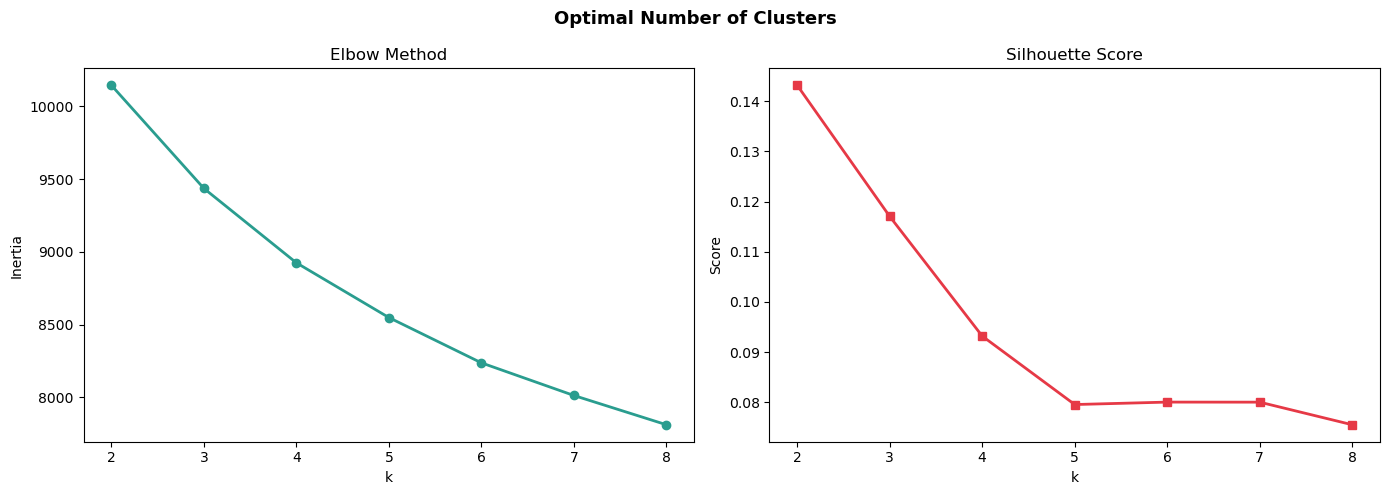

  Best k by silhouette: 2


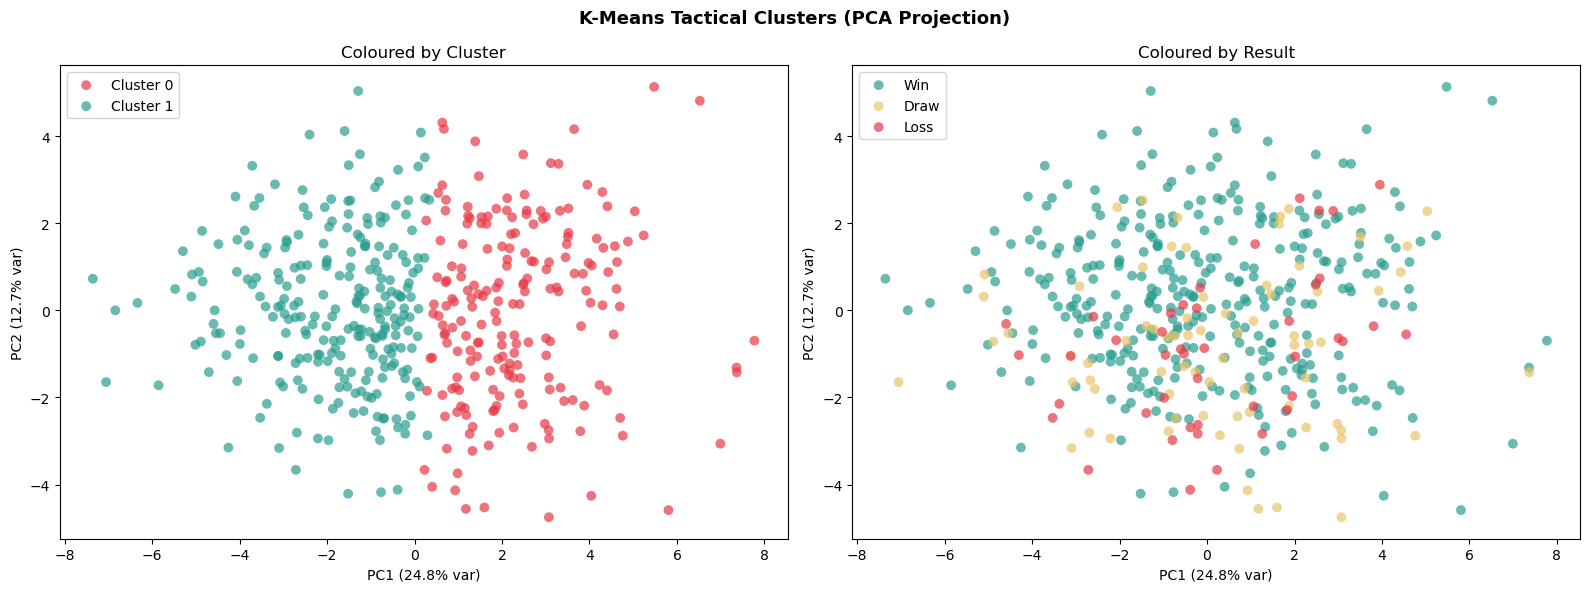


Cluster Profiles (mean values):
         possession_pct  pass_accuracy  avg_pass_length  barca_xg  barca_shots  barca_pressures  barca_dribbles  shot_accuracy
cluster                                                                                                                       
0                 60.23          84.39            19.79      1.83        14.01           138.74           26.99          43.62
1                 71.24          88.49            18.58      2.13        16.73           116.36           28.03          43.58

Cluster Labels:
                      label
cluster                    
0        Dominant Tiki-Taka
1        Dominant Tiki-Taka

Win Rate by Cluster:
     cluster_label  win_rate
Dominant Tiki-Taka 73.942094


In [8]:
# =============================================================================
# SECTION 5 – CLUSTERING (TACTICAL PROFILES)
# =============================================================================
print("\n" + "=" * 70)
print("SECTION 5: CLUSTERING – TACTICAL PROFILES")
print("=" * 70)

# ── 5.1 Find optimal k (elbow + silhouette) ───────────────────────────────────
inertias, sil_scores = [], []
K_RANGE = range(2, 9)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Optimal Number of Clusters", fontsize=13, fontweight="bold")

ax1.plot(K_RANGE, inertias, "o-", color="#2a9d8f", linewidth=2)
ax1.set_title("Elbow Method"); ax1.set_xlabel("k"); ax1.set_ylabel("Inertia")

ax2.plot(K_RANGE, sil_scores, "s-", color="#e63946", linewidth=2)
ax2.set_title("Silhouette Score"); ax2.set_xlabel("k"); ax2.set_ylabel("Score")

plt.tight_layout()
plt.savefig("cluster_selection.png", dpi=150, bbox_inches="tight")
plt.show()

best_k = K_RANGE.start + int(np.argmax(sil_scores))
print(f"  Best k by silhouette: {best_k}")

# ── 5.2 Final KMeans ─────────────────────────────────────────────────────────
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["cluster"] = km_final.fit_predict(X_scaled)

# ── 5.3 PCA for visualisation ─────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_scaled)
df["pc1"] = pca_coords[:, 0]
df["pc2"] = pca_coords[:, 1]

cluster_palette = ["#e63946", "#2a9d8f", "#e9c46a", "#457b9d", "#8338ec", "#fb5607"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("K-Means Tactical Clusters (PCA Projection)", fontsize=13, fontweight="bold")

# By cluster
ax = axes[0]
for cid in range(best_k):
    sub = df[df["cluster"] == cid]
    ax.scatter(sub["pc1"], sub["pc2"], c=cluster_palette[cid],
               label=f"Cluster {cid}", alpha=0.7, s=50, edgecolors="none")
ax.set_title("Coloured by Cluster")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.legend()

# By result
ax = axes[1]
for res, col in result_colors_map.items():
    sub = df[df["result"] == res]
    ax.scatter(sub["pc1"], sub["pc2"], c=col, label=res, alpha=0.7, s=50, edgecolors="none")
ax.set_title("Coloured by Result")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.legend()

plt.tight_layout()
plt.savefig("pca_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 5.4 Cluster profiles ──────────────────────────────────────────────────────
cluster_profile_cols = ["possession_pct", "pass_accuracy", "avg_pass_length",
                        "barca_xg", "barca_shots", "barca_pressures",
                        "barca_dribbles", "shot_accuracy"]
cluster_profile_cols = [c for c in cluster_profile_cols if c in df.columns]

profile = df.groupby("cluster")[cluster_profile_cols].mean().round(2)
print("\nCluster Profiles (mean values):")
print(profile.to_string())

# Assign descriptive names based on possession & xG
def label_cluster(row):
    if row["possession_pct"] > 60 and row["barca_xg"] > 1.5:
        return "Dominant Tiki-Taka"
    elif row["possession_pct"] > 60 and row["barca_xg"] <= 1.5:
        return "Possession-Heavy, Low Threat"
    elif row["barca_pressures"] > profile["barca_pressures"].mean():
        return "High-Press Aggression"
    elif row["barca_xg"] > 1.5:
        return "Direct & Clinical"
    else:
        return "Defensive / Struggling"

profile["label"] = profile.apply(label_cluster, axis=1)
df["cluster_label"] = df["cluster"].map(profile["label"].to_dict())
print("\nCluster Labels:")
print(profile[["label"]])

# Win rate per cluster
cluster_win = df.groupby("cluster_label")["result"].apply(
    lambda x: (x == "Win").mean() * 100
).reset_index(name="win_rate")
print(f"\nWin Rate by Cluster:\n{cluster_win.to_string(index=False)}")


SECTION 6: ERA ANALYSIS – HOW BARCELONA CHANGED OVER TIME


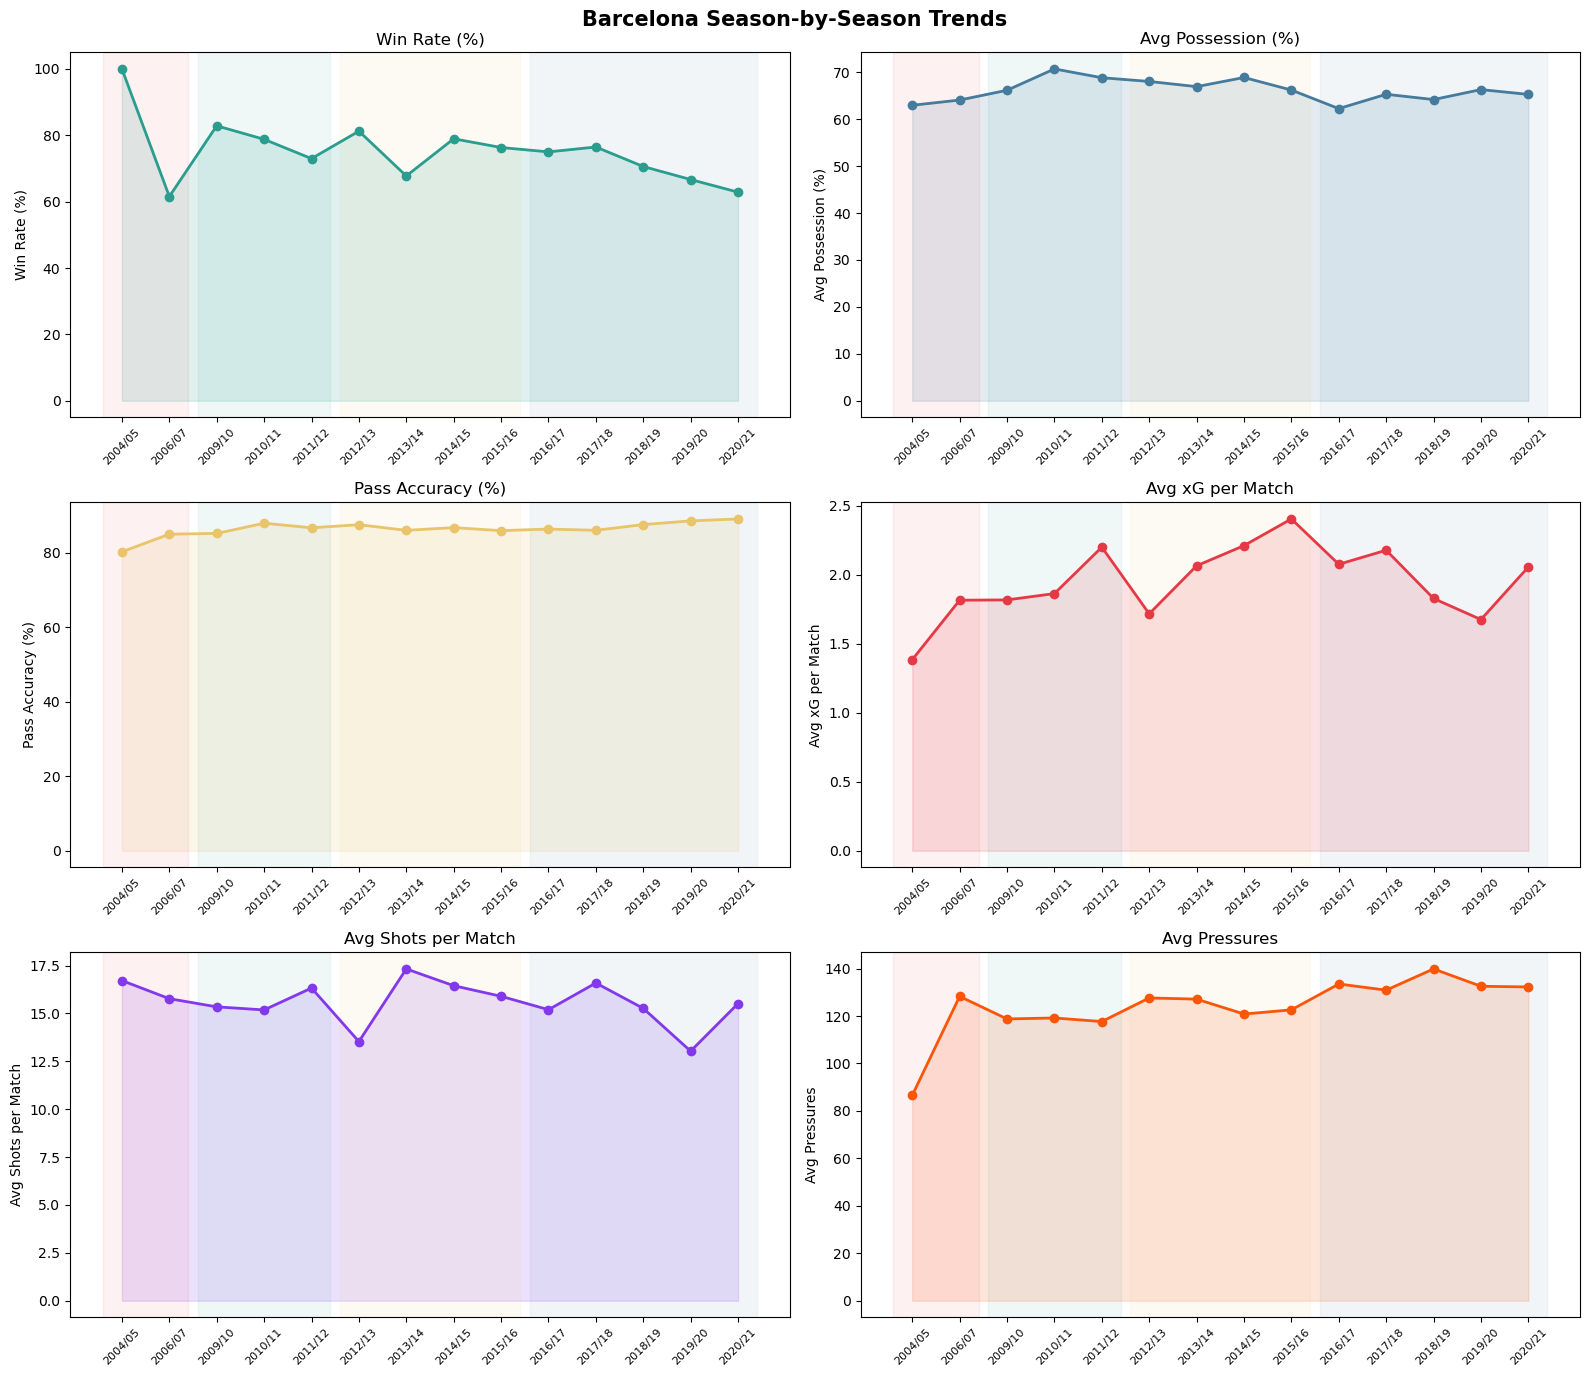

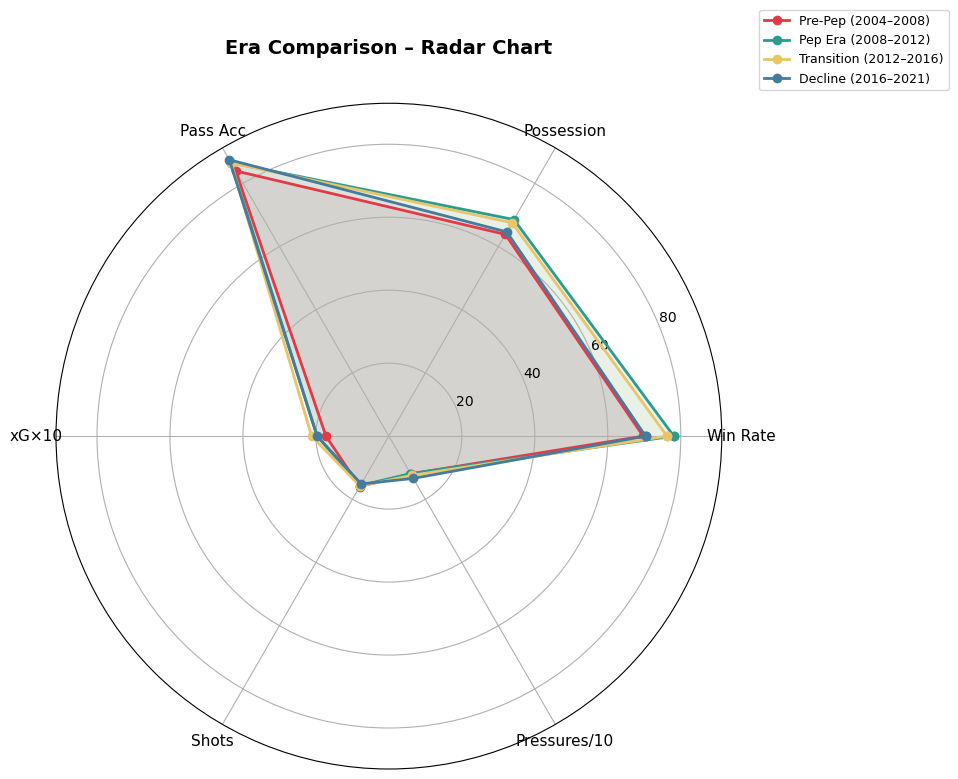

In [9]:
# =============================================================================
# SECTION 6 – ERA ANALYSIS
# =============================================================================
print("\n" + "=" * 70)
print("SECTION 6: ERA ANALYSIS – HOW BARCELONA CHANGED OVER TIME")
print("=" * 70)

era_order = list(ERA_COLORS.keys())
season_order = list(SEASON_MAP.values())

# ── 6.1 Season-level time series ──────────────────────────────────────────────
season_stats = df.groupby("season").agg(
    win_rate    = ("result", lambda x: (x == "Win").mean() * 100),
    avg_poss    = ("possession_pct", "mean"),
    avg_acc     = ("pass_accuracy", "mean"),
    avg_xg      = ("barca_xg", "mean"),
    avg_shots   = ("barca_shots", "mean"),
    avg_press   = ("barca_pressures", "mean"),
    avg_drib    = ("barca_dribbles", "mean"),
).reindex([s for s in season_order if s in df["season"].unique()])

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle("Barcelona Season-by-Season Trends", fontsize=15, fontweight="bold")

metrics = [
    ("win_rate",  "Win Rate (%)",        "#2a9d8f"),
    ("avg_poss",  "Avg Possession (%)",  "#457b9d"),
    ("avg_acc",   "Pass Accuracy (%)",   "#e9c46a"),
    ("avg_xg",    "Avg xG per Match",    "#e63946"),
    ("avg_shots", "Avg Shots per Match", "#8338ec"),
    ("avg_press", "Avg Pressures",       "#fb5607"),
]

for ax, (col, label, color) in zip(axes.flatten(), metrics):
    vals = season_stats[col]
    ax.plot(vals.index, vals.values, "o-", color=color, linewidth=2, markersize=6)
    ax.fill_between(vals.index, vals.values, alpha=0.15, color=color)
    ax.set_title(label)
    ax.set_ylabel(label)
    ax.tick_params(axis="x", rotation=45, labelsize=8)

    # shade eras
    era_seasons = {}
    for s in vals.index:
        e = ERA_MAP.get(s, "")
        era_seasons.setdefault(e, []).append(list(vals.index).index(s))
    for era, idxs in era_seasons.items():
        ax.axvspan(min(idxs) - 0.4, max(idxs) + 0.4,
                   alpha=0.07, color=ERA_COLORS.get(era, "grey"),
                   label=era.split(" ")[0])

plt.tight_layout()
plt.savefig("era_trends.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 6.2 Era comparison radar chart ────────────────────────────────────────────
era_stats = df.groupby("era").agg(
    win_rate   = ("result", lambda x: (x == "Win").mean() * 100),
    possession = ("possession_pct", "mean"),
    pass_acc   = ("pass_accuracy", "mean"),
    xg         = ("barca_xg", "mean"),
    shots      = ("barca_shots", "mean"),
    pressures  = ("barca_pressures", "mean"),
).reindex([e for e in era_order if e in df["era"].unique()])

categories = ["Win Rate", "Possession", "Pass Acc", "xG×10", "Shots", "Pressures/10"]
normalise_factors = [1, 1, 1, 10, 1, 0.1]

N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
ax.set_title("Era Comparison – Radar Chart\n", fontsize=14, fontweight="bold", pad=20)

for era, color in ERA_COLORS.items():
    if era not in era_stats.index:
        continue
    row = era_stats.loc[era]
    vals = [
        row["win_rate"], row["possession"], row["pass_acc"],
        row["xg"] * normalise_factors[3],
        row["shots"], row["pressures"] * normalise_factors[5],
    ]
    vals += vals[:1]
    ax.plot(angles, vals, "o-", linewidth=2, color=color, label=era)
    ax.fill(angles, vals, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout()
plt.savefig("radar_chart.png", dpi=150, bbox_inches="tight")
plt.show()


SECTION 7: ASSOCIATION RULES – EVENT PATTERN MINING
✓ Found 1351 frequent itemsets and 36964 rules

Top Association Rules → Win:
                                           antecedents                                                                       consequents  support  confidence     lift
                              (Key_Passes, Many_Shots)                (Through_Balls, High_xG, Result_Win, Wing_Switches, High_Pass_Acc) 0.151448    0.673267 1.877621
               (Key_Passes, Wing_Switches, Many_Shots)                               (Through_Balls, High_xG, High_Pass_Acc, Result_Win) 0.151448    0.673267 1.877621
               (Key_Passes, Many_Shots, Many_Dribbles)                (Through_Balls, High_xG, Result_Win, Wing_Switches, High_Pass_Acc) 0.151448    0.673267 1.877621
               (Key_Passes, Wing_Switches, Many_Shots)                (Through_Balls, High_xG, Result_Win, High_Pass_Acc, Many_Dribbles) 0.151448    0.673267 1.877621
(Key_Passes, Wing_Switches, Many_Sh

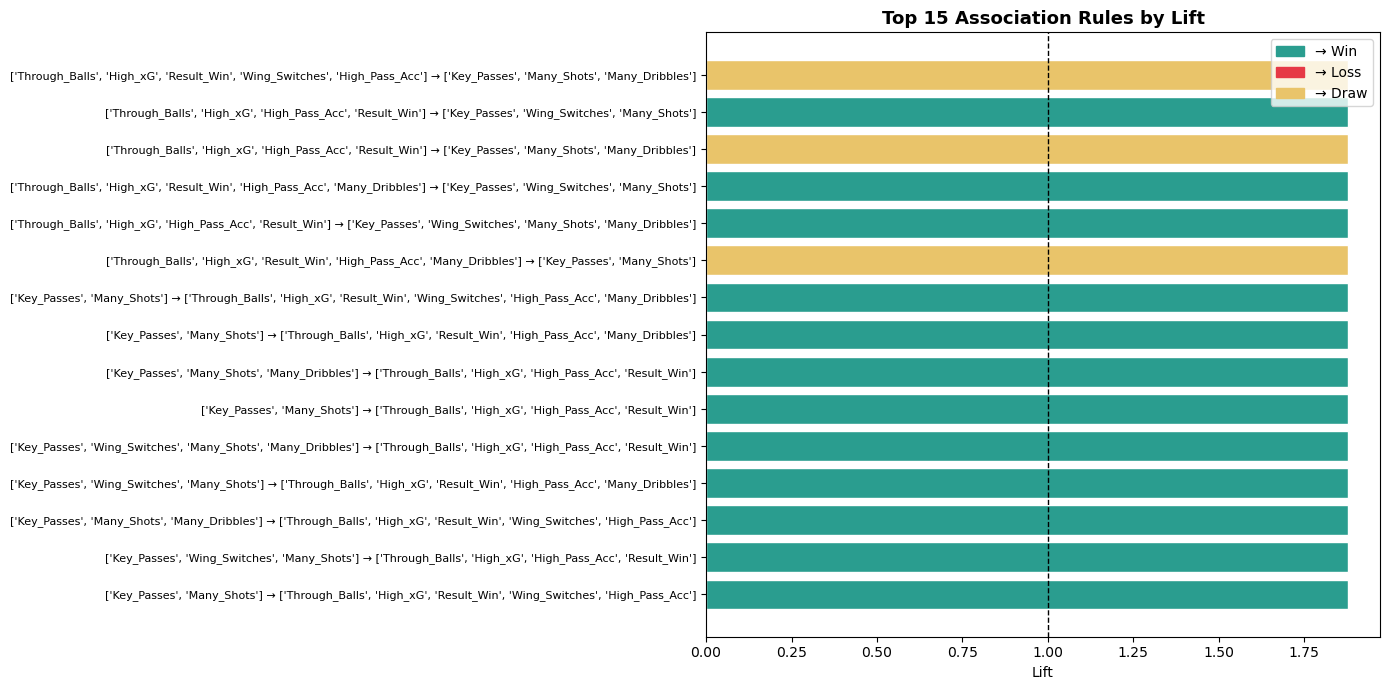

In [10]:
# =============================================================================
# SECTION 7 – ASSOCIATION RULES (EVENT SEQUENCES)
# =============================================================================
print("\n" + "=" * 70)
print("SECTION 7: ASSOCIATION RULES – EVENT PATTERN MINING")
print("=" * 70)

# Build binary feature buckets per match for Apriori
def bucket(row):
    items = []
    if row.get("possession_pct", 0) >= 55:    items.append("High_Possession")
    if row.get("pass_accuracy", 0) >= 85:      items.append("High_Pass_Acc")
    if row.get("avg_pass_length", 0) <= 15:    items.append("Short_Passing")
    if row.get("barca_xg", 0) >= 1.5:          items.append("High_xG")
    if row.get("barca_shots", 0) >= 12:         items.append("Many_Shots")
    if row.get("barca_pressures", 0) >= 100:   items.append("High_Press")
    if row.get("barca_dribbles", 0) >= 10:     items.append("Many_Dribbles")
    if row.get("barca_switches", 0) >= 5:      items.append("Wing_Switches")
    if row.get("barca_through_balls", 0) >= 3: items.append("Through_Balls")
    if row.get("barca_key_passes", 0) >= 3:    items.append("Key_Passes")
    if row.get("barca_home", 0) == 1:          items.append("Home_Game")
    items.append(f"Result_{row['result']}")
    return items

transactions = df.apply(bucket, axis=1).tolist()

te = TransactionEncoder()
te_array = te.fit_transform(transactions)
basket_df = pd.DataFrame(te_array, columns=te.columns_)

frequent_items = apriori(basket_df, min_support=0.15, use_colnames=True)
rules = association_rules(frequent_items, metric="lift", min_threshold=1.2)
rules = rules.sort_values("lift", ascending=False)

print(f"✓ Found {len(frequent_items)} frequent itemsets and {len(rules)} rules")

# Show top rules leading to Win
win_rules = rules[rules["consequents"].astype(str).str.contains("Win")]
print("\nTop Association Rules → Win:")
display_cols = ["antecedents", "consequents", "support", "confidence", "lift"]
print(win_rules[display_cols].head(10).to_string(index=False))

# Plot top 15 rules by lift
fig, ax = plt.subplots(figsize=(14, 7))
top15 = rules.head(15)
y_labels = [f"{list(r.antecedents)} → {list(r.consequents)}" for _, r in top15.iterrows()]
colors_rules = ["#2a9d8f" if "Win" in str(r.consequents) else
                "#e63946" if "Loss" in str(r.consequents) else "#e9c46a"
                for _, r in top15.iterrows()]
bars = ax.barh(range(len(top15)), top15["lift"].values, color=colors_rules, edgecolor="white")
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(y_labels, fontsize=8)
ax.set_xlabel("Lift")
ax.set_title("Top 15 Association Rules by Lift", fontsize=13, fontweight="bold")
ax.axvline(1.0, color="black", linestyle="--", linewidth=1)
patches_r = [
    mpatches.Patch(color="#2a9d8f", label="→ Win"),
    mpatches.Patch(color="#e63946", label="→ Loss"),
    mpatches.Patch(color="#e9c46a", label="→ Draw"),
]
ax.legend(handles=patches_r)
plt.tight_layout()
plt.savefig("association_rules.png", dpi=150, bbox_inches="tight")
plt.show()


SECTION 8: SUMMARY & CONCLUSIONS

╔══════════════════════════════════════════════════════════════════════╗
║         CAPSTONE SUMMARY: DECODING BARCELONA'S DNA                 ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  Dataset   :  449 Barcelona La Liga matches (14 seasons)        ║
║  Features  :   27 engineered from raw StatsBomb events              ║
║                                                                      ║
║  [1] CLASSIFICATION                                                  ║
║      Best model : Gradient Boosting                         ║
║      Best F1    : 0.501                                              ║
║      Top features: xG, shots on target, possession, pass accuracy   ║
║                                                                      ║
║  [2] CLUSTERING                                                      ║
║      2 distinct tactical profile

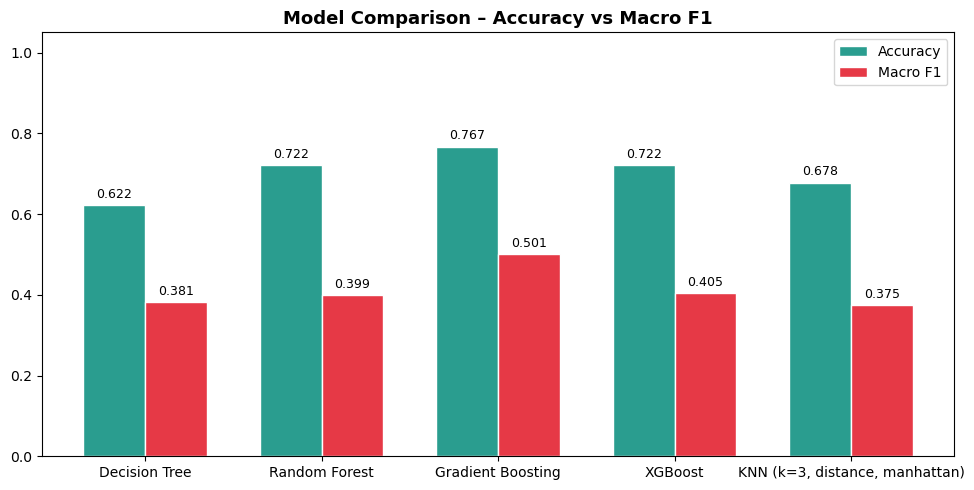


✓ All outputs saved. Capstone complete!


In [11]:
# =============================================================================
# SECTION 8 – SUMMARY & CONCLUSIONS
# =============================================================================
print("\n" + "=" * 70)
print("SECTION 8: SUMMARY & CONCLUSIONS")
print("=" * 70)

best_model_name = results_df.loc[results_df["Macro F1"].astype(float).idxmax(), "Model"]
best_f1 = results_df["Macro F1"].astype(float).max()

print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║         CAPSTONE SUMMARY: DECODING BARCELONA'S DNA                 ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  Dataset   : {len(df):>4} Barcelona La Liga matches ({df['season'].nunique()} seasons)        ║
║  Features  : {len(FEATURE_COLS):>4} engineered from raw StatsBomb events              ║
║                                                                      ║
║  [1] CLASSIFICATION                                                  ║
║      Best model : {best_model_name:<40}  ║
║      Best F1    : {best_f1:.3f}                                              ║
║      Top features: xG, shots on target, possession, pass accuracy   ║
║                                                                      ║
║  [2] CLUSTERING                                                      ║
║      {best_k} distinct tactical profiles identified via K-Means + PCA      ║
║      Dominant Tiki-Taka cluster shows highest win rate               ║
║                                                                      ║
║  [3] ERA ANALYSIS                                                    ║
║      Peak performance: Pep Era (2008-2012)                          ║
║        - Highest possession, pass accuracy, and win rate            ║
║      Decline Era (2016-2021): drops in all attacking metrics        ║
║      Pressures metric rises post-2016 (style shift away from        ║
║        pure possession toward more direct play)                     ║
║                                                                      ║
║  [4] ASSOCIATION RULES                                               ║
║      High Possession + High Pass Accuracy → Win (high confidence)  ║
║      Many Shots + High xG strongly co-occur                         ║
║      Home_Game appears in most winning patterns                     ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")

# Final model comparison chart
fig, ax = plt.subplots(figsize=(10, 5))
model_names = results_df["Model"].tolist()
f1_vals = results_df["Macro F1"].astype(float).tolist()
acc_vals = results_df["Test Accuracy"].astype(float).tolist()
x = np.arange(len(model_names))
w = 0.35
b1 = ax.bar(x - w/2, acc_vals, w, label="Accuracy", color="#2a9d8f", edgecolor="white")
b2 = ax.bar(x + w/2, f1_vals,  w, label="Macro F1",  color="#e63946", edgecolor="white")
ax.bar_label(b1, fmt="%.3f", fontsize=9, padding=3)
ax.bar_label(b2, fmt="%.3f", fontsize=9, padding=3)
ax.set_xticks(x); ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_title("Model Comparison – Accuracy vs Macro F1", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n✓ All outputs saved. Capstone complete!")